# The rarest bullish candle in the book, put to the test ⭐⭐⭐
### Three stars in the south — three shrinking red candles that are
### supposed to say "the selling is over"

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_downtrend_base_rate%3F: Mixed](https://img.shields.io/badge/Beats_a_downtrend_base_rate%3F-Mixed-8b949e?style=flat-square)

Deep in a downtrend, the story goes, you sometimes see something odd: three red (down) candles in a row, but each one is **smaller** than the last, and each one's low sits **higher** than the one before. Sellers are still pushing the stock down — but with visibly less and less conviction each day, like a wave running out of energy on the beach. The third candle barely has a body at all. Candlestick lore calls this **three stars in the south**, and claims it marks the exact moment selling pressure runs out.

That's the claim we test: *does the shrinking, rising-low shape itself signal exhaustion?* Spoiler up front — this is the rarest pattern this desk has ever measured, and the honest answer is that there simply isn't enough real-world evidence to say yes.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** SPY + 60 long-listed US large-caps, ~25 years of daily bars (yfinance). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_stars_in_the_south import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
else:
    PANEL = None
print("real cache present:", HAVE_REAL, "| basket size:", len(data.BASKET))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_names': 61, 'years': 25.0, 'total_bars': 383080, 'n_loose': 363, 'n_strict': 5, 'bonferroni_crit': 2.5, 'loose_rate_txt': 'once per ~4.2 ticker-years', 'strict_rate_txt': 'once per ~305 ticker-years', 'loose': {1: (21.9, 55.1, 2.4, 19.5, 2.26, 0.015, 11.9), 5: (43.3, 54.8, 28.8, 14.5, 0.74, 0.263, 33.3), 10: (69.2, 57.6, 57.2, 12.0, 0.45, 0.349, 59.2), 20: (90.3, 55.9, 119.4, -29.1, -0.8, 0.768, 80.3)}, 'strict': {1: (37.6, 60.0, 35.2, 0.302, 27.6), 5: (-57.9, 40.0, -86.7, 0.719, -67.9), 10: (27.8, 60.0, -29.4, 0.555, 17.8), 20: (133.0, 40.0, 13.6, 0.486, 123.0)}, 'strict_events': [('TXN', '2006-10-18', '2006-10-20', -303.3), ('CAT', '2021-06-14', '2021-06-16', -256.3), ('BDX', '2016-09-16', '2016-09-20', -210.2), ('AXP', '2019-03-27', '2019-03-29', 624.1), ('COST', '2024-10-24', '2024-10-28', 810.9)], 'syn_null_mean': -0.34, 'syn_null_sd': 1.08, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_e02_t': 7.44, 'syn_e02_delta': 156.0, 'syn_e04_t': 16.16, 'syn_e04_delta': 346.9, 'fp_spy': '27b74051eb44', 'fp_panel': '16a85c8367ed'}


real cache present: True | basket size: 61


## The answer first

| Question | Answer |
|---|---|
| Does a shrinking, rising-low three-star block predict a bounce? | **Not provably.** The plain (loose) reading fires **363** times across 61 stocks and 25 years — enough to test — and the 1-day reaction looks promising (+19.5 bps more than a normal downtrend bar) but the effect **flips negative** by 20 days, and none of it survives the correction for testing four different holding periods at once. |
| What about the *real*, strict version from the textbook? | It happens **5 times** in 25 years across 61 stocks — once per ~305 ticker-years. That's too few data points for any statistic to mean anything. |
| So which is it — real or fake? | **We genuinely can't tell**, and that's the honest finding. Two of the five real occurrences led to sharp bounces (+624 bps, +811 bps); three didn't (the stock kept falling). A coin flip would look similar. |
| Can you trade it? | **No.** Even setting statistics aside, a pattern that shows up once every 305 ticker-years per stock has no capacity to matter. |

> Not every piece of market folklore gets a clean "busted" — some are simply too rare to ever put on trial properly, and that's worth saying plainly.

## 1 · The claim

> *"After a sustained decline, watch for three consecutive black candles where each one is smaller than the last and each low is higher than the one before. The third candle is barely more than a sliver. This tells you the bears are exhausted — buy."*

Unlike most reversal patterns, three stars in the south doesn't even need a green candle to confirm it — the shrinking, rising-low shape of three *red* candles is claimed to be the signal all by itself. Steve Nison, who introduced Western traders to Japanese candlesticks, includes it in his canon — but even Thomas Bulkowski, who has statistically tested hundreds of chart patterns on decades of data, admits he couldn't find enough real examples to rank this one with confidence. That admission is itself a finding worth taking seriously before we even open the data.

## 2 · So what?

If real, this would be a genuinely elegant signal: no waiting for a confirming green candle, no gap required — just read the *shape* of the selling itself as it happens, and get in a day early. That's valuable if it works. But it's also the kind of claim that's easy to believe once you've seen a few pretty chart examples and easy to over-trust because it *sounds* mechanically sensible ("of course shrinking sell pressure means selling is ending") without ever being tested on enough real cases to know.

## 3 · How would we even know?

- **The shape, two ways.** A **loose** reading (three shrinking, rising-low black candles in a downtrend) that fires often enough to test, and a **strict**, textbook-faithful reading (+ a hammer-like first candle, no gap on the second, a near-doji third that never undercuts the second) that is the actual literature claim.
- **The comparison.** The forward return after the pattern vs. the forward return from buying **any** bar that's already in a similar downtrend — isolating the pattern's own information from plain "buy the dip."
- **The luck check.** Draw random downtrend days instead of real three-star days — how often does chance alone produce as good a result?
- **The honesty rule.** If either cut fires too rarely to compute a meaningful statistic, we say so instead of dressing up a handful of points as a verdict.

## 4 · The teardown — let's actually look

**First, the loose cut.** Forward return after the pattern vs. the downtrend base rate, at four holding periods.

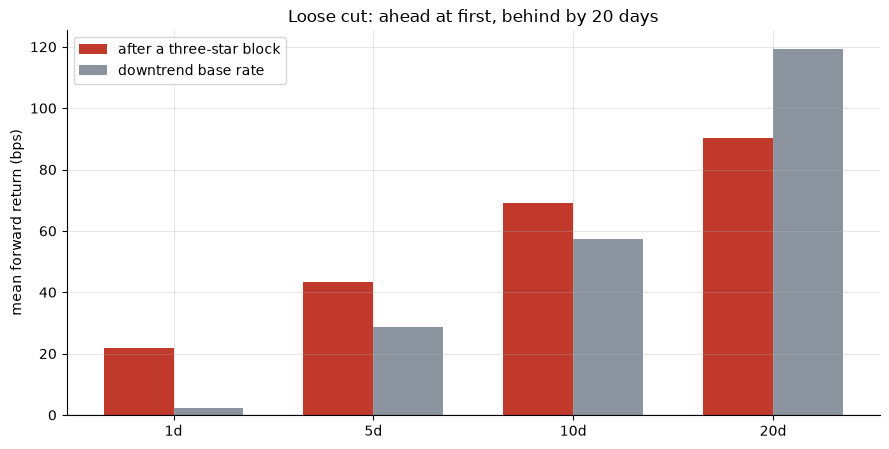

{1: (21.9, 2.4, 2.26), 5: (43.3, 28.8, 0.74), 10: (69.2, 57.2, 0.45), 20: (90.3, 119.4, -0.8)}


In [2]:
if HAVE_REAL:
    res = st.run_experiment(PANEL)
    loose = {h: (res['per_horizon'][h]['star']['mean_bps'],
                 res['per_horizon'][h]['base']['mean_bps'],
                 res['per_horizon'][h]['welch_t']) for h in st.HORIZONS}
else:
    loose = {h: (R['loose'][h][0], R['loose'][h][2], R['loose'][h][4]) for h in (1,5,10,20)}
hs = sorted(loose)
star_v = [loose[h][0] for h in hs]
base_v = [loose[h][1] for h in hs]
x = np.arange(len(hs)); w = 0.35
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.bar(x - w/2, star_v, w, color=RED, label='after a three-star block')
ax.bar(x + w/2, base_v, w, color=GREY, label='downtrend base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward return (bps)')
ax.set_title('Loose cut: ahead at first, behind by 20 days')
ax.legend(); plt.tight_layout(); plt.show()
print({h: (round(loose[h][0],1), round(loose[h][1],1), round(loose[h][2],2)) for h in hs})

At 1 day the pattern looks promising: **+21.9 bps** vs **+2.4 bps** for the base rate — a real-looking gap (Welch *t* = 2.26). But look at 20 days: **+90.3 bps** for the pattern vs **+119.4 bps** for the base rate — the pattern is now *behind*. A genuine exhaustion signal shouldn't reverse itself as you hold longer. Once you account for testing four different holding periods at once (the statistical equivalent of getting four lottery tickets instead of one), **nothing here clears the bar**.

**Now the real thing — the strict, textbook-faithful cut.**

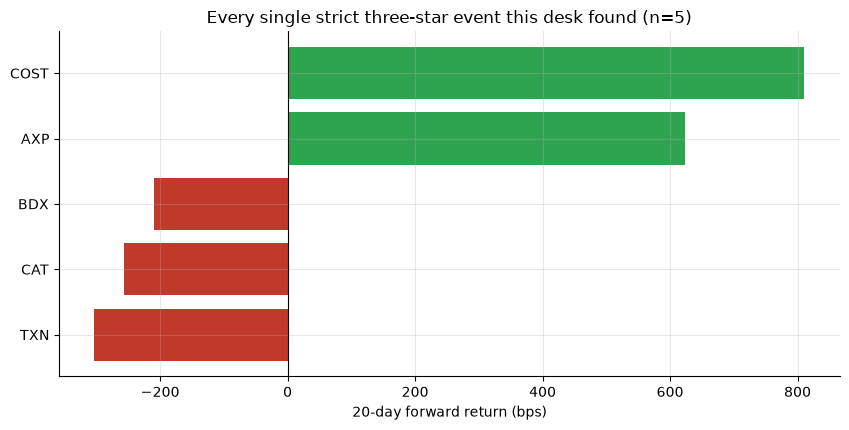

TXN: 2006-10-18 -> 2006-10-20   20d -303.3 bps
CAT: 2021-06-14 -> 2021-06-16   20d -256.3 bps
BDX: 2016-09-16 -> 2016-09-20   20d -210.2 bps
AXP: 2019-03-27 -> 2019-03-29   20d +624.1 bps
COST: 2024-10-24 -> 2024-10-28   20d +810.9 bps


In [3]:
if HAVE_REAL:
    ev = st.pool_events(PANEL)
    strict_ev = ev[ev['strict']].copy()
    recs = []
    for _, row in strict_ev.iterrows():
        tkr = row['ticker']; bars = PANEL[tkr]; pos = int(row['pos'])
        d0 = bars.index[pos - 2].date(); d1 = bars.index[pos].date()
        recs.append((tkr, str(d0), str(d1), row['ret_20'] * 1e4))
    recs.sort(key=lambda r: r[3])
else:
    recs = sorted(R['strict_events'], key=lambda r: r[3])
fig, ax = plt.subplots(figsize=(8.6, 4.4))
labels = [r[0] for r in recs]; vals = [r[3] for r in recs]
ax.barh(labels, vals, color=[RED if v < 0 else GREEN for v in vals])
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('20-day forward return (bps)')
ax.set_title(f'Every single strict three-star event this desk found (n={len(recs)})')
plt.tight_layout(); plt.show()
for r in recs: print(f'{r[0]}: {r[1]} -> {r[2]}   20d {r[3]:+.1f} bps')

This is not a summary statistic — this chart shows **every single** literature-faithful three-star block found across 61 stocks and 25 years: **5**. Two led to sharp bounces (AXP +624 bps, COST +811 bps); three did not (TXN, CAT, BDX kept falling). With five data points, that split is exactly what you'd expect from pure chance. We can name the pattern, chart it beautifully, and still honestly say: **we do not have enough real occurrences to know if it works.**

**Finally, does the harness even work?** We plant a fake three-star effect in simulated data and confirm the same machinery can find it when it's really there.

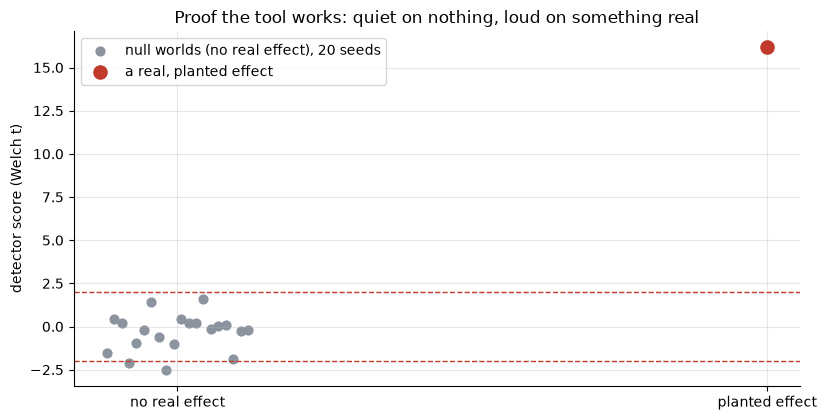

no-effect worlds: mean -0.34  |  planted-effect world: +16.16


In [4]:
null_ts = []
for s_ in range(20):
    d, truth = data.synthetic_panel(edge=0.0, seed=690 + s_)
    r = st.synthetic_detect(d, horizon=20, seed=690 + s_, active_masks=truth['active_masks'])
    if r['welch_t'] is not None:
        null_ts.append(r['welch_t'])
d2, truth2 = data.synthetic_panel(edge=0.04, seed=690)
planted = st.synthetic_detect(d2, horizon=20, seed=690, active_masks=truth2['active_masks'])
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.scatter(np.zeros(len(null_ts)) + np.linspace(-.12,.12,len(null_ts)), null_ts,
           color=GREY, s=40, label='null worlds (no real effect), 20 seeds')
ax.scatter([1], [planted['welch_t']], color=RED, s=90, zorder=5, label='a real, planted effect')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['no real effect', 'planted effect'])
ax.set_ylabel('detector score (Welch t)')
ax.set_title('Proof the tool works: quiet on nothing, loud on something real')
ax.legend(); plt.tight_layout(); plt.show()
print(f'no-effect worlds: mean {np.mean(null_ts):+.2f}  |  planted-effect world: {planted["welch_t"]:+.2f}')

When we simulate 20 fake worlds with **no** real three-star effect, the detector correctly stays quiet (scores clustered near zero). When we plant a genuine effect, it lights up unmistakably. So the tool isn't broken — the real market simply hasn't handed us enough genuine three-star events to say either way.

## 5 · The verdict

- **Signal — None.** The loose cut looks interesting for exactly one day before reversing, and nothing survives the correction for testing four holding periods. The strict, textbook cut has only 5 real occurrences in 25 years — too few for any statistic to mean anything.
- **Tradability — Mirage.** Once per 305 ticker-years for the real version of the pattern. That's not a strategy, it's a museum piece.
- **"Beats a downtrend base rate?" — Mixed.** Points the right way at short horizons before flipping; the five real strict events split roughly 50/50 between real bounces and continued declines — a coin flip's worth of evidence either way.

## 6 · Going further 🚪

- **Rarity itself is the finding.** When a respected chart-pattern statistician like Bulkowski says he couldn't find enough examples to rank a pattern, that's worth believing *before* running a single test — and this study's real-tape count (5 events) backs him up precisely.
- **The nearby, testable cousins already exist on this desk:** [three white soldiers](../../187-three-soldiers/) (the bullish continuation mirror), [three black crows](../../408-three-black-crows/) (the bearish momentum cousin that shares the "three black candles" costume but claims the opposite thing), and [ladder bottom](../../687-ladder-bottom/) (a related 5-candle bottoming pattern with enough real occurrences to actually test).

*Have a bigger basket, or more history? The full detector and event list are reproducible from [examples/verify.py](../examples/verify.py) — five events is a starting point, not a final word.*